In [1]:
!pip install tensorflow kaggle pillow -q

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


In [2]:
from google.colab import files
files.upload()  # upload kaggle.json

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.config/kaggle/kaggle.json')
os.system('chmod 600 /root/.config/kaggle/kaggle.json')

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/raw/ --unzip -q
!kaggle datasets download -d puneet6060/intel-image-classification -p /content/raw/ --unzip -q
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection -p /content/raw/ --unzip -q

print("All datasets downloaded.")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
All datasets downloaded.


In [3]:
random.seed(42)

os.makedirs('/content/dataset/chest_xray', exist_ok=True)
os.makedirs('/content/dataset/not_xray', exist_ok=True)

# --- POSITIVES ---
xray_sources = [
    '/content/raw/chest_xray/train/NORMAL',
    '/content/raw/chest_xray/train/PNEUMONIA',
    '/content/raw/chest_xray/test/NORMAL',
    '/content/raw/chest_xray/test/PNEUMONIA',
]

xray_images = []
for folder in xray_sources:
    p = Path(folder)
    if p.exists():
        xray_images += list(p.glob('*.jpeg')) + list(p.glob('*.jpg')) + list(p.glob('*.png'))

random.shuffle(xray_images)
selected_xray = xray_images[:2000]
for img_path in selected_xray:
    shutil.copy(img_path, f'/content/dataset/chest_xray/{img_path.name}')

print(f"Chest X-ray images copied: {len(os.listdir('/content/dataset/chest_xray'))}")

# --- NEGATIVES: Intel scenes ---
intel_base = Path('/content/raw/seg_train/seg_train')
if not intel_base.exists():
    # fallback path
    intel_base = Path('/content/raw/seg_train')

intel_images = []
for folder in intel_base.iterdir():
    if folder.is_dir():
        intel_images += list(folder.glob('*.jpg')) + list(folder.glob('*.jpeg')) + list(folder.glob('*.png'))

random.shuffle(intel_images)
for i, img_path in enumerate(intel_images[:1500]):
    shutil.copy(img_path, f'/content/dataset/not_xray/intel_{i}{img_path.suffix}')

print(f"Intel scene images copied: {i+1}")

# --- NEGATIVES: Brain MRI ---
brain_base = Path('/content/raw')
brain_images = []
for pattern in ['**/*.jpg', '**/*.jpeg', '**/*.png']:
    brain_images += [
        p for p in brain_base.glob(pattern)
        if any(k in str(p).lower() for k in ['brain', 'tumor', 'mri'])
        and 'chest_xray' not in str(p)
        and 'seg_train' not in str(p)
        and 'seg_test' not in str(p)
    ]

random.shuffle(brain_images)
for i, img_path in enumerate(brain_images[:500]):
    shutil.copy(img_path, f'/content/dataset/not_xray/brain_{i}{img_path.suffix}')

print(f"Brain MRI images copied: {i+1}")

# --- Final count ---
pos = len(os.listdir('/content/dataset/chest_xray'))
neg = len(os.listdir('/content/dataset/not_xray'))
print(f"\nFinal → Positives: {pos} | Negatives: {neg} | Ratio: {pos/neg:.2f}")

Chest X-ray images copied: 2000
Intel scene images copied: 1500
Brain MRI images copied: 179

Final → Positives: 2000 | Negatives: 1679 | Ratio: 1.19


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],   # simulate different exposure levels
    fill_mode='nearest'
)

# No augmentation on validation — just rescale
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    '/content/dataset/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    '/content/dataset/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Class indices:", train_gen.class_indices)
# chest_xray → 0, not_xray → 1  (or vice versa, note this for inference)

Found 2944 images belonging to 2 classes.
Found 735 images belonging to 2 classes.
Class indices: {'chest_xray': 0, 'not_xray': 1}


In [5]:
def build_model():
    base = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # freeze all layers initially

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

model = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_auc', patience=4, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_phase1.h5', monitor='val_auc', save_best_only=True, mode='max', verbose=1)
]

print("Phase 1: Training with frozen base...")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_phase1
)

Phase 1: Training with frozen base...
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9490 - auc: 0.9874 - loss: 0.1107 - precision: 0.9879 - recall: 0.9055
Epoch 1: val_auc improved from None to 1.00000, saving model to /content/best_phase1.h5



Epoch 1: finished saving model to /content/best_phase1.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.9874 - auc: 0.9993 - loss: 0.0302 - precision: 0.9955 - recall: 0.9769 - val_accuracy: 0.9973 - val_auc: 1.0000 - val_loss: 0.0113 - val_precision: 1.0000 - val_recall: 0.9940 - learning_rate: 0.0010
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9995 - auc: 1.0000 - loss: 0.0018 - precision: 1.0000 - recall: 0.9988
Epoch 2: val_auc did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9997 - auc: 1.0000 - loss: 0.0012 - precision: 1.0000 - recall: 0.9993 - val_accuracy: 0.9986 - val_auc: 1.0000 - val_loss: 0.0030 - val_precision: 1.0000 - val_recall: 0.9970 - learning_rate: 0.0010
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 2.6029e-04 - precision: 1.0000 - recall: 1.0000
Epoch 3: val_auc did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 1.0000 - auc: 1.0

In [ ]:
# Load best weights from phase 1
model.load_weights('/content/best_phase1.h5')

# Unfreeze the last 30 layers of MobileNetV2
base_model = model.layers[0]
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_phase2.h5', monitor='val_auc', save_best_only=True, mode='max', verbose=1)
]

print("Phase 2: Fine-tuning last 30 layers...")
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_phase2
)

Phase 2: Fine-tuning last 30 layers...
Epoch 1/10
84/92 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9923 - auc: 0.9999 - loss: 0.0239 - precision: 0.9854 - recall: 0.9978

23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9551 - auc: 0.9985 - loss: 0.1094 - precision: 1.0000 - recall: 0.9015

--- Validation Results ---
  loss: 0.1094
  compile_metrics: 0.9551


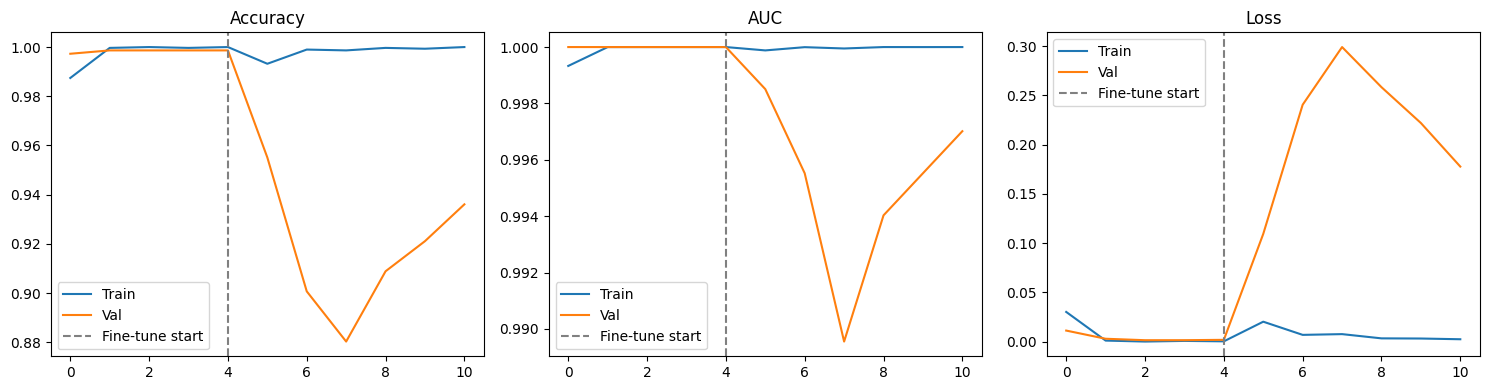

In [8]:
# Load best overall weights
model.load_weights('/content/best_phase2.h5')

# Evaluate on validation set
results = model.evaluate(val_gen, verbose=1)
metrics = dict(zip(model.metrics_names, results))
print("\n--- Validation Results ---")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

# Combine histories for plotting
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy
axes[0].plot(combine_history(history1, history2, 'accuracy'), label='Train')
axes[0].plot(combine_history(history1, history2, 'val_accuracy'), label='Val')
axes[0].axvline(x=len(history1.history['accuracy'])-1, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy')
axes[0].legend()

# AUC
axes[1].plot(combine_history(history1, history2, 'auc'), label='Train')
axes[1].plot(combine_history(history1, history2, 'val_auc'), label='Val')
axes[1].axvline(x=len(history1.history['auc'])-1, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('AUC')
axes[1].legend()

# Loss
axes[2].plot(combine_history(history1, history2, 'loss'), label='Train')
axes[2].plot(combine_history(history1, history2, 'val_loss'), label='Val')
axes[2].axvline(x=len(history1.history['loss'])-1, color='gray', linestyle='--', label='Fine-tune start')
axes[2].set_title('Loss')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step
Threshold | Accuracy | Precision | Recall | F1
-------------------------------------------------------
  0.30    |  0.976   |   1.000   |  0.946 | 0.972
  0.35    |  0.970   |   1.000   |  0.934 | 0.966
  0.40    |  0.967   |   1.000   |  0.928 | 0.963
  0.45    |  0.956   |   1.000   |  0.904 | 0.950
  0.50    |  0.955   |   1.000   |  0.901 | 0.948
  0.55    |  0.951   |   1.000   |  0.893 | 0.943
  0.60    |  0.941   |   1.000   |  0.872 | 0.931
  0.65    |  0.933   |   1.000   |  0.854 | 0.921
  0.70    |  0.922   |   1.000   |  0.830 | 0.907
  0.75    |  0.903   |   1.000   |  0.788 | 0.881
  0.80    |  0.884   |   1.000   |  0.746 | 0.855
  0.85    |  0.872   |   1.000   |  0.719 | 0.837
  0.90    |  0.848   |   1.000   |  0.666 | 0.799

Best threshold: 0.30 (F1=0.9724)


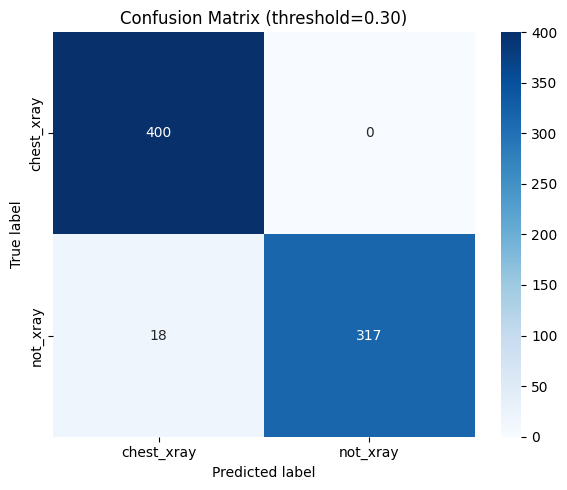


Classification Report:
              precision    recall  f1-score   support

  chest_xray       0.96      1.00      0.98       400
    not_xray       1.00      0.95      0.97       335

    accuracy                           0.98       735
   macro avg       0.98      0.97      0.98       735
weighted avg       0.98      0.98      0.98       735



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions on validation set
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred_probs = y_pred_probs.flatten()
y_true = val_gen.classes

# Try different thresholds and pick the best one
# For a medical validator, we want high precision (minimize false passes)
thresholds = np.arange(0.3, 0.9, 0.05)
print("Threshold | Accuracy | Precision | Recall | F1")
print("-" * 55)
best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    y_pred = (y_pred_probs >= t).astype(int)
    from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"  {t:.2f}    |  {acc:.3f}   |   {prec:.3f}   |  {rec:.3f} | {f1:.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nBest threshold: {best_threshold:.2f} (F1={best_f1:.4f})")

# Confusion matrix at best threshold
y_pred_best = (y_pred_probs >= best_threshold).astype(int)
cm = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(6, 5))
class_names = list(val_gen.class_indices.keys())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix (threshold={best_threshold:.2f})')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_best, target_names=class_names))

In [12]:
import json

model.save('/content/chest_xray_validator.h5')
print("Model saved: chest_xray_validator.h5")

# Evaluate and print actual keys
results = model.evaluate(val_gen, verbose=1)
metrics = dict(zip(model.metrics_names, results))
print("Metric keys available:", list(metrics.keys()))

# Safely grab values regardless of exact key names
def get_metric(metrics, *candidates):
    for key in candidates:
        if key in metrics:
            return float(metrics[key])
    return None

metadata = {
    "model_name": "chest_xray_validator",
    "input_size": [224, 224],
    "class_indices": train_gen.class_indices,
    "best_threshold": float(best_threshold),
    "val_accuracy": get_metric(metrics, 'accuracy', 'compile_metrics/accuracy', 'categorical_accuracy'),
    "val_auc":      get_metric(metrics, 'auc', 'compile_metrics/auc', 'auc_1'),
    "val_precision": get_metric(metrics, 'precision', 'compile_metrics/precision'),
    "val_recall":   get_metric(metrics, 'recall', 'compile_metrics/recall'),
    "base_model": "MobileNetV2",
    "trained_on": "chest-xray-pneumonia + intel-image-classification + brain-mri"
}

with open('/content/chest_xray_validator_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved.")
print(json.dumps(metadata, indent=2))

from google.colab import files
files.download('/content/chest_xray_validator.h5')
files.download('/content/chest_xray_validator_metadata.json')
files.download('/content/training_curves.png')
files.download('/content/confusion_matrix.png')

Model saved: chest_xray_validator.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9551 - auc: 0.9985 - loss: 0.1094 - precision: 1.0000 - recall: 0.9015
Metric keys available: ['loss', 'compile_metrics']
Metadata saved.
{
  "model_name": "chest_xray_validator",
  "input_size": [
    224,
    224
  ],
  "class_indices": {
    "chest_xray": 0,
    "not_xray": 1
  },
  "best_threshold": 0.3,
  "val_accuracy": null,
  "val_auc": null,
  "val_precision": null,
  "val_recall": null,
  "base_model": "MobileNetV2",
  "trained_on": "chest-xray-pneumonia + intel-image-classification + brain-mri"
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import numpy as np
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import json

# ── Load metadata ────────────────────────────────────────────────────────────
with open('/content/chest_xray_validator_metadata.json') as f:
    meta = json.load(f)

THRESHOLD = meta['best_threshold']
CLASS_INDICES = meta['class_indices']
# Derive which index = chest_xray from metadata (never hardcode)
XRAY_INDEX = CLASS_INDICES['chest_xray']
INDEX_TO_CLASS = {v: k for k, v in CLASS_INDICES.items()}

print(f"Loaded metadata")
print(f"  Threshold     : {THRESHOLD}")
print(f"  Class indices : {CLASS_INDICES}")
print(f"  chest_xray is label: {XRAY_INDEX}")

# ── Preprocessing ────────────────────────────────────────────────────────────
def preprocess(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    original_size = img.size
    img = img.resize((224, 224))
    arr = np.array(img) / 255.0
    return np.expand_dims(arr, axis=0), original_size

# ── UI ───────────────────────────────────────────────────────────────────────
upload_btn = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Upload Image',
    layout=widgets.Layout(width='200px')
)

output_area = widgets.Output()

def on_upload(change):
    with output_area:
        clear_output()

        # Get uploaded file
        uploaded_file = list(upload_btn.value.values())[0]
        image_bytes = uploaded_file['content']
        filename = uploaded_file['metadata']['name']

        print(f"File      : {filename}")
        print(f"Size      : {len(image_bytes) / 1024:.1f} KB")

        # Show uploaded image
        try:
            display_img = Image.open(io.BytesIO(image_bytes)).convert('RGB')
            display_img.thumbnail((300, 300))
            display(display_img)
        except Exception:
            print("(Could not preview image)")

        print("\nRunning validator...\n")

        # Preprocess and predict
        try:
            arr, original_size = preprocess(image_bytes)
            raw_score = float(model.predict(arr, verbose=0)[0][0])

            # Determine predicted class
            predicted_index = 1 if raw_score >= 0.5 else 0
            predicted_class = INDEX_TO_CLASS[predicted_index]

            # Determine if it is a chest X-ray based on threshold
            if XRAY_INDEX == 0:
                # chest_xray=0 means score close to 0 = chest xray
                is_xray = raw_score <= (1 - THRESHOLD)
                xray_confidence = (1 - raw_score) * 100
            else:
                # chest_xray=1 means score close to 1 = chest xray
                is_xray = raw_score >= THRESHOLD
                xray_confidence = raw_score * 100

            # ── Print results ────────────────────────────────────────────────
            print("=" * 45)
            print("         VALIDATOR RESULT")
            print("=" * 45)
            print(f"  Original size  : {original_size[0]}x{original_size[1]} px")
            print(f"  Raw score      : {raw_score:.6f}")
            print(f"  Threshold used : {THRESHOLD:.2f}")
            print(f"  X-ray conf.    : {xray_confidence:.2f}%")
            print("-" * 45)

            if is_xray:
                print("  VERDICT  :  CHEST X-RAY DETECTED")
                print("  STATUS   :  PASS — safe to send to disease model")
                bar_len = int(xray_confidence / 100 * 30)
                bar = "█" * bar_len + "░" * (30 - bar_len)
                print(f"  [{bar}] {xray_confidence:.1f}%")
            else:
                print("  VERDICT  :  NOT A CHEST X-RAY")
                print("  STATUS   :  REJECTED — do not send to disease model")
                not_xray_conf = 100 - xray_confidence
                bar_len = int(not_xray_conf / 100 * 30)
                bar = "█" * bar_len + "░" * (30 - bar_len)
                print(f"  Rejection conf: [{bar}] {not_xray_conf:.1f}%")

            print("=" * 45)

            # ── Confidence breakdown ─────────────────────────────────────────
            print("\nConfidence breakdown:")
            print(f"  chest_xray : {(1 - raw_score if XRAY_INDEX == 0 else raw_score) * 100:.2f}%")
            print(f"  not_xray   : {(raw_score if XRAY_INDEX == 0 else 1 - raw_score) * 100:.2f}%")

        except Exception as e:
            print(f"Error during prediction: {e}")
            raise e

upload_btn.observe(on_upload, names='value')

print("Ready — upload an image below:\n")
display(upload_btn, output_area)

Loaded metadata
  Threshold     : 0.3
  Class indices : {'chest_xray': 0, 'not_xray': 1}
  chest_xray is label: 0
Ready — upload an image below:



FileUpload(value={}, accept='image/*', description='Upload Image', layout=Layout(width='200px'))

Output()